# **Import Library dan Pengaturan GPU**

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
import time

# Pastikan GPU terdeteksi di Kaggle
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('GPU tidak ditemukan, pastikan setting Accelerator di Kaggle sudah diubah ke GPU T4.')
else:
    print('Sukses! Menemukan GPU pada:', device_name)

Sukses! Menemukan GPU pada: /device:GPU:0


I0000 00:00:1781597113.669765      58 gpu_device.cc:2019] Created device /device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781597113.671504      58 gpu_device.cc:2019] Created device /device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# **Memuat dan Memfilter Dataset 1 (CIFAR-10 untuk CNN from Scratch)**

In [11]:
# Fungsi untuk memfilter hanya 2 kelas (0: Airplane, 1: Automobile)
def filter_two_classes(image, label):
    mask = tf.math.less(label, 2)
    return mask

# Load dataset CIFAR-10 asli
(ds_train_cifar, ds_test_cifar), ds_info_cifar = tfds.load(
    'cifar10',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)

# Gabungkan dulu semua data untuk difilter dan dibagi ulang sesuai rasio 70:15:15
ds_all_cifar = ds_train_cifar.concatenate(ds_test_cifar)
ds_filtered_cifar = ds_all_cifar.filter(filter_two_classes)

# Hitung total data biner yang didapat
DATASET_SIZE = sum(1 for _ in ds_filtered_cifar)
print(f"Total gambar biner CIFAR-10 (Airplane vs Car): {DATASET_SIZE}")

# Lakukan splitting (70% Train, 15% Val, 15% Test)
train_size = int(0.70 * DATASET_SIZE)
val_size = int(0.15 * DATASET_SIZE)
test_size = DATASET_SIZE - train_size - val_size

ds_cifar_train = ds_filtered_cifar.take(train_size)
ds_cifar_val_test = ds_filtered_cifar.skip(train_size)
ds_cifar_val = ds_cifar_val_test.take(val_size)
ds_cifar_test = ds_cifar_val_test.skip(val_size)

# Preprocessing: Normalisasi pixel gambar (0-255 menjadi 0-1)
def preprocess_cifar(image, label):
    image = tf.image.resize(image, (32, 32))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

BATCH_SIZE = 32
cifar_train = ds_cifar_train.map(preprocess_cifar).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
cifar_val = ds_cifar_val.map(preprocess_cifar).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
cifar_test = ds_cifar_test.map(preprocess_cifar).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Split data selesai. Train: {train_size}, Val: {val_size}, Test: {test_size}")

Total gambar biner CIFAR-10 (Airplane vs Car): 12000
Split data selesai. Train: 8400, Val: 1800, Test: 1800


# **Memuat dan Menyiapkan Dataset 2 (Cats vs Dogs untuk Transfer Learning)**

In [12]:
# Load dataset Cats vs Dogs
ds_all_dogs_cats, ds_info_dogs_cats = tfds.load(
    'cats_vs_dogs',
    split='train',
    as_supervised=True,
    with_info=True
)

D_C_SIZE = sum(1 for _ in ds_all_dogs_cats)
print(f"Total gambar Cats vs Dogs asli: {D_C_SIZE}")

# Batasi atau bagi langsung 70:15:15
dc_train_size = int(0.70 * D_C_SIZE)
dc_val_size = int(0.15 * D_C_SIZE)
dc_test_size = D_C_SIZE - dc_train_size - dc_val_size

ds_dc_train = ds_all_dogs_cats.take(dc_train_size)
ds_dc_val_test = ds_all_dogs_cats.skip(dc_train_size)
ds_dc_val = ds_dc_val_test.take(dc_val_size)
ds_dc_test = ds_dc_val_test.skip(dc_val_size)

# Preprocessing Cats vs Dogs (Resize ke 160x160 untuk MobileNetV2 dan normalisasi ke [-1, 1])
def preprocess_dc(image, label):
    image = tf.image.resize(image, (160, 160))
    image = tf.cast(image, tf.float32)
    image = (image / 127.5) - 1.0  # Formula rescaling bawaan MobileNet
    return image, label

dc_train = ds_dc_train.map(preprocess_dc).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
dc_val = ds_dc_val.map(preprocess_dc).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
dc_test = ds_dc_test.map(preprocess_dc).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Split Cats vs Dogs selesai. Train: {dc_train_size}, Val: {dc_val_size}, Test: {dc_test_size}")

Total gambar Cats vs Dogs asli: 23262
Split Cats vs Dogs selesai. Train: 16283, Val: 3489, Test: 3490


# **Eksperimen 1 — Pembuatan & Training Model CNN from Scratch**

In [13]:
# Desain Arsitektur CNN From Scratch
model_scratch = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # Regularisasi untuk mengurangi risiko overfitting
    layers.Dense(1, activation='sigmoid') # 1 unit Sigmoid untuk klasifikasi 2 kelas
])

model_scratch.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_scratch.summary()

# Proses Training dan Pencatatan Waktu
start_time = time.time()
history_scratch = model_scratch.fit(
    cifar_train,
    epochs=10, # Kamu bisa naikkan epoch-nya nanti jika dirasa kurang
    validation_data=cifar_val
)
scratch_duration = time.time() - start_time
print(f"Waktu training CNN from Scratch: {scratch_duration:.2f} detik")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,985 (476.50 KB)

 Trainable params: 121,985 (476.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
    263/Unknown 7s 13ms/step - accuracy: 0.7010 - loss: 0.5528

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.7861 - loss: 0.4526 - val_accuracy: 0.8294 - val_loss: 0.3830
Epoch 2/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8660 - loss: 0.3144 - val_accuracy: 0.8961 - val_loss: 0.2635
Epoch 3/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9080 - loss: 0.2419 - val_accuracy: 0.9189 - val_loss: 0.1998
Epoch 4/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9231 - loss: 0.1979 - val_accuracy: 0.9311 - val_loss: 0.1695
Epoch 5/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9377 - loss: 0.1570 - val_accuracy: 0.9278 - val_loss: 0.1976
Epoch 6/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9467 - loss: 0.1426 - val_accuracy: 0.9322 - val_loss: 0.1663
Epoch 7/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9542 - loss: 0.1198 - val_accuracy: 0.9389 - val_loss: 0.1669
Epoch 8/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9596 - loss: 0.1065 - val_accuracy: 0.92

# **Eksperimen 2 — Pembuatan & Training Model Transfer Learning**

In [14]:
# Menggunakan Pretrained Model MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False, # Keluarkan classifier aslinya
    weights='imagenet'
)

# Strategi Feature Extraction: Bekukan semua base layer
base_model.trainable = False

# Satukan base model dengan classifier baru kita
model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_tl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_tl.summary()

# Proses Training Transfer Learning
start_time = time.time()
history_tl = model_tl.fit(
    dc_train,
    epochs=5, # Transfer learning biasanya konvergen jauh lebih cepat
    validation_data=dc_val
)
tl_duration = time.time() - start_time
print(f"Waktu training Transfer Learning: {tl_duration:.2f} detik")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 40s 62ms/step - accuracy: 0.9743 - loss: 0.0732 - val_accuracy: 0.9794 - val_loss: 0.0566
Epoch 2/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.9823 - loss: 0.0481 - val_accuracy: 0.9814 - val_loss: 0.0497
Epoch 3/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.9861 - loss: 0.0395 - val_accuracy: 0.9822 - val_loss: 0.0481
Epoch 4/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.9878 - loss: 0.0344 - val_accuracy: 0.9814 - val_loss: 0.0534
Epoch 5/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.9882 - loss: 0.0320 - val_accuracy: 0.9805 - val_loss: 0.0565
Waktu training Transfer Learning: 120.97 detik


# **Evaluasi Akhir pada Data Testing**

In [15]:
# Evaluasi CNN from Scratch
loss_scratch_test, acc_scratch_test = model_scratch.evaluate(cifar_test)
print(f"Scratch Test Accuracy: {acc_scratch_test*100:.2f}%")

# Evaluasi Transfer Learning
loss_tl_test, acc_tl_test = model_tl.evaluate(dc_test)
print(f"Transfer Learning Test Accuracy: {acc_tl_test*100:.2f}%")

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9511 - loss: 0.1492
Scratch Test Accuracy: 95.11%
110/110 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - accuracy: 0.9831 - loss: 0.0538
Transfer Learning Test Accuracy: 98.31%


# **Visualisasi Grafik Loss & Akurasi**

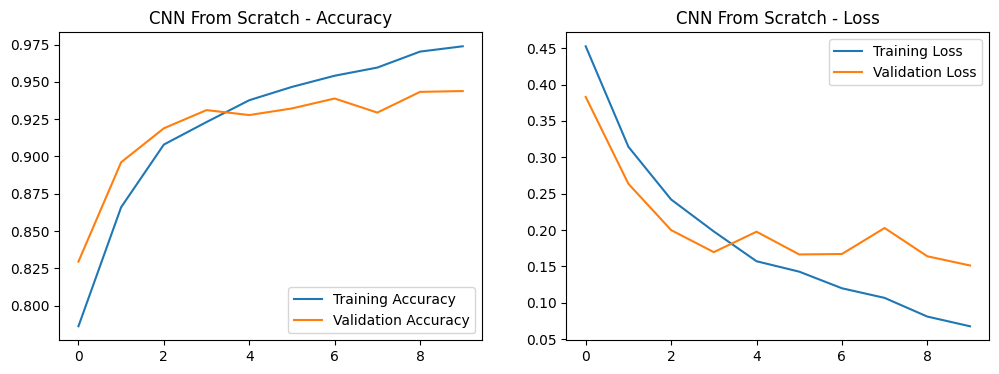

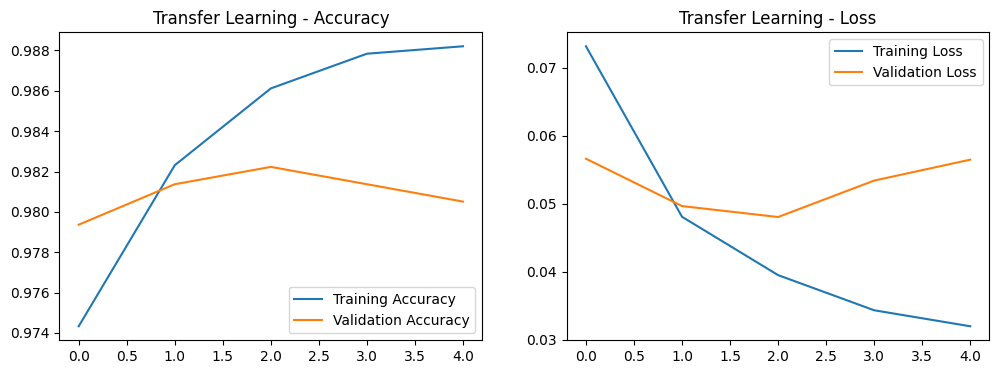

In [16]:
def plot_metrics(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title(f'{title} - Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title(f'{title} - Loss')
    plt.show()

# Panggil fungsi visualisasi
plot_metrics(history_scratch, "CNN From Scratch")
plot_metrics(history_tl, "Transfer Learning")

# **Pembuatan Confusion Matrix**

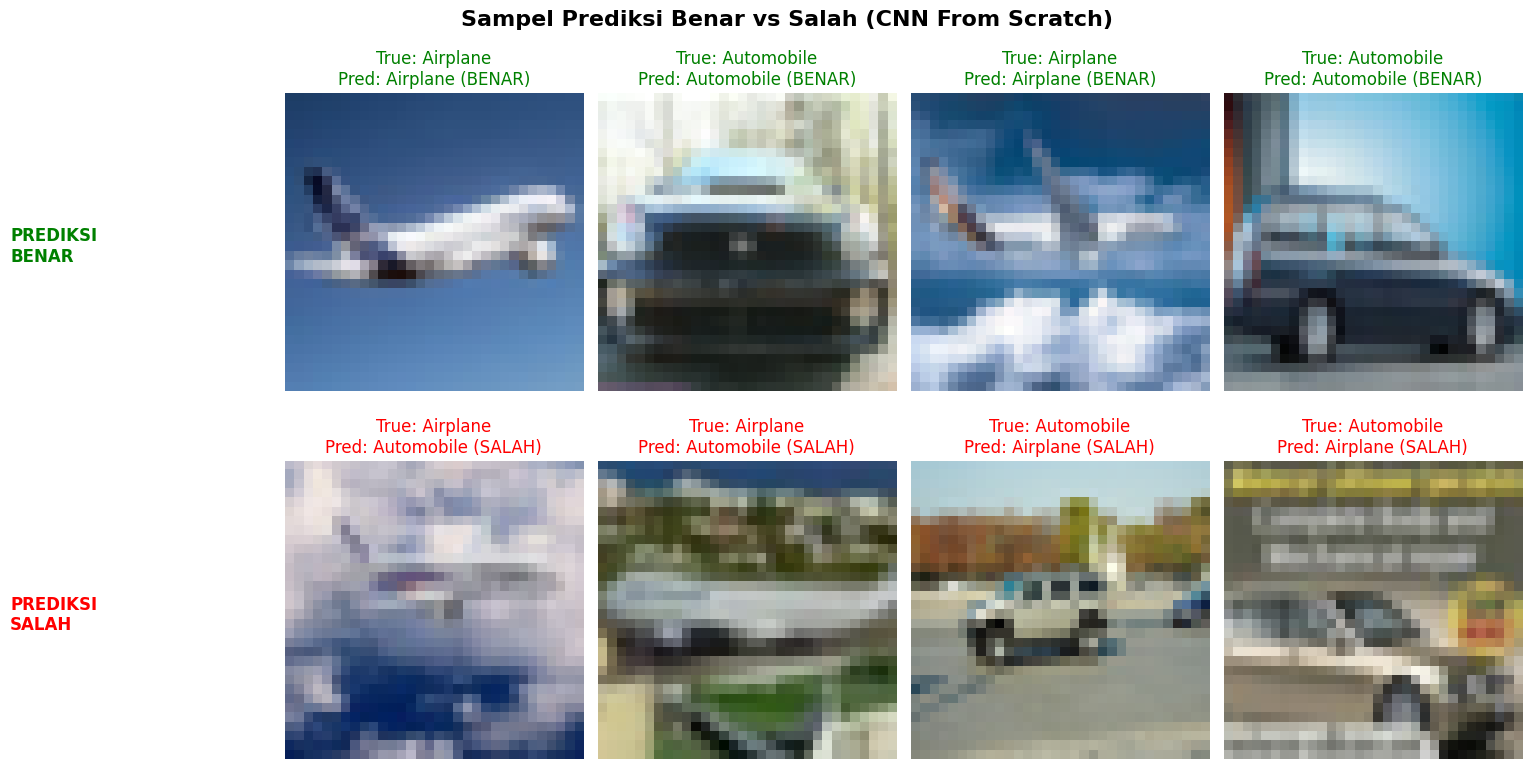

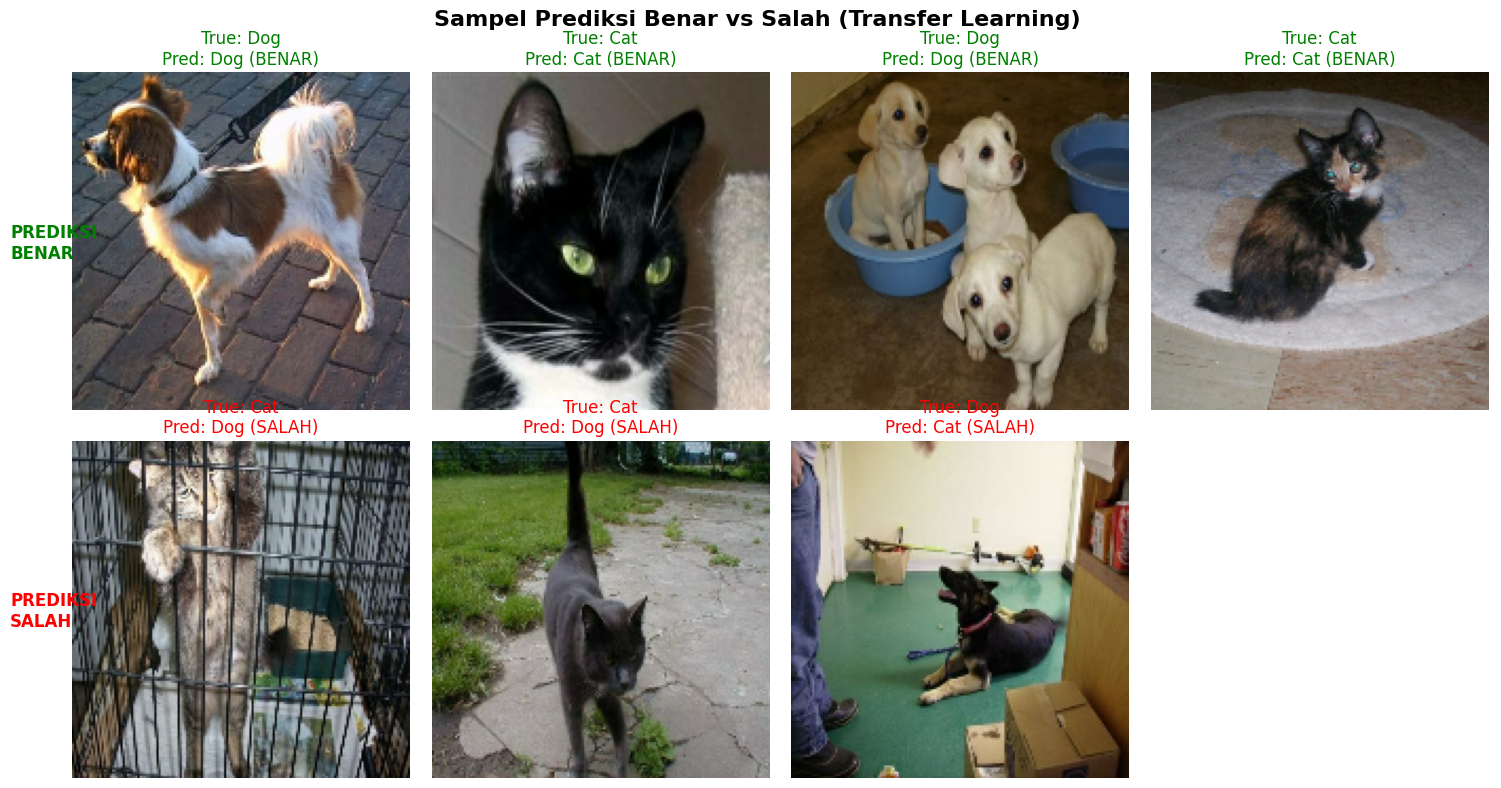

In [17]:
def display_prediction_samples(model, dataset, title, class_names, is_transfer_learning=False):
    all_images = []
    all_labels = []
    all_preds = []
    
    # Ambil data dari batch testing
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        preds = np.where(preds > 0.5, 1, 0).flatten()
        
        all_images.extend(images.numpy())
        all_labels.extend(labels.numpy())
        all_preds.extend(preds)
        
        # Berhenti jika sudah mengumpulkan cukup sampel untuk efisiensi
        if len(all_images) >= 100:
            break
            
    all_images = np.array(all_images)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    
    # Cari indeks yang benar dan yang salah
    correct_idx = np.where(all_labels == all_preds)[0]
    incorrect_idx = np.where(all_labels != all_preds)[0]
    
    # Setup plot (2 baris: baris atas PREDIKSI BENAR, baris bawah PREDIKSI SALAH)
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    fig.suptitle(f'Sampel Prediksi Benar vs Salah ({title})', fontsize=16, fontweight='bold')
    
    # 1. Plot 4 Sampel BENAR (Baris Pertama)
    for i in range(4):
        ax = axes[0, i]
        if i < len(correct_idx):
            idx = correct_idx[i]
            img = all_images[idx]
            
            # Balikkan preprocessing jika ini model Transfer Learning (dari [-1,1] ke [0,1])
            if is_transfer_learning:
                img = (img + 1.0) / 2.0
                img = np.clip(img, 0.0, 1.0)
                
            ax.imshow(img)
            ax.set_title(f"True: {class_names[all_labels[idx]]}\nPred: {class_names[all_preds[idx]]} (BENAR)", color='green')
        ax.axis('off')
        if i == 0:
            ax.text(-30, img.shape[0]//2, "PREDIKSI\nBENAR", fontsize=12, fontweight='bold', color='green', va='center')

    # 2. Plot 4 Sampel SALAH (Baris Kedua)
    for i in range(4):
        ax = axes[1, i]
        if i < len(incorrect_idx):
            idx = incorrect_idx[i]
            img = all_images[idx]
            
            # Balikkan preprocessing jika ini model Transfer Learning (dari [-1,1] ke [0,1])
            if is_transfer_learning:
                img = (img + 1.0) / 2.0
                img = np.clip(img, 0.0, 1.0)
                
            ax.imshow(img)
            ax.set_title(f"True: {class_names[all_labels[idx]]}\nPred: {class_names[all_preds[idx]]} (SALAH)", color='red')
        ax.axis('off')
        if i == 0:
            ax.text(-30, img.shape[0]//2, "PREDIKSI\nSALAH", fontsize=12, fontweight='bold', color='red', va='center')
            
    plt.tight_layout()
    plt.show()

# --- EKSEKUSI FUNGSI ---
# Tampilkan sampel prediksi untuk CNN from Scratch (CIFAR-10)
display_prediction_samples(model_scratch, cifar_test, "CNN From Scratch", ['Airplane', 'Automobile'], is_transfer_learning=False)

# Tampilkan sampel prediksi untuk Transfer Learning (Cats vs Dogs)
display_prediction_samples(model_tl, dc_test, "Transfer Learning", ['Cat', 'Dog'], is_transfer_learning=True)

# **Pembuatan Tabel Perbandingan Otomatis**

In [18]:
print(f"{'Aspek':<25} | {'CNN from Scratch':<20} | {'Transfer Learning':<20}")
print("-" * 72)
print(f"{'Akurasi Training':<25} | {history_scratch.history['accuracy'][-1]:<20.4f} | {history_tl.history['accuracy'][-1]:<20.4f}")
print(f"{'Akurasi Validation':<25} | {history_scratch.history['val_accuracy'][-1]:<20.4f} | {history_tl.history['val_accuracy'][-1]:<20.4f}")
print(f"{'Akurasi Testing':<25} | {acc_scratch_test:<20.4f} | {acc_tl_test:<20.4f}")
print(f"{'Loss Training':<25} | {history_scratch.history['loss'][-1]:<20.4f} | {history_tl.history['loss'][-1]:<20.4f}")
print(f"{'Loss Validation':<25} | {history_scratch.history['val_loss'][-1]:<20.4f} | {history_tl.history['val_loss'][-1]:<20.4f}")
print(f"{'Waktu Training':<25} | {f'{scratch_duration:.2f} s':<20} | {f'{tl_duration:.2f} s':<20}")
print(f"{'Jumlah Parameter':<25} | {model_scratch.count_params():<20,} | {model_tl.count_params():<20,}")

Aspek                     | CNN from Scratch     | Transfer Learning   
------------------------------------------------------------------------
Akurasi Training          | 0.9739               | 0.9882              
Akurasi Validation        | 0.9439               | 0.9805              
Akurasi Testing           | 0.9511               | 0.9831              
Loss Training             | 0.0675               | 0.0320              
Loss Validation           | 0.1511               | 0.0565              
Waktu Training            | 52.24 s              | 120.97 s            
Jumlah Parameter          | 121,985              | 2,340,033           
